# Structured Products: <BR> Estimating the payoff distribution using simulations
    
In this notebook, we investigate the distribution of the payoffs achieved by some of the structured products presented in the sp_examples notebook. To do so, we will assume that the DGP of the underlying is an NGARCH model, and will simply rely on the parameters estimated in the ngarch_estimation notebook. 

In [10]:
%matplotlib inline
import internal_script

import datetime as dt
import numpy as np
import os
import pandas as pd
import pandas_datareader as pdr
import pickle
import matplotlib.pyplot as plt
from scipy import stats
from pandas.tseries.holiday import USFederalHolidayCalendar

from dorion_francois.instruments import Bond, Spot, Call, Put, DownAndOutPut, DigitalCall, DigitalPut
from dorion_francois.plot_utils import (mpl, plt, mtick, mdates, gridspec,
                            set_plt_defaults, set_payoff_axes, set_time_axis, with_style)
from dorion_francois.toolkit import print_versions, tic, toc
from dorion_francois.volatility_models import ngarch, plot_parameter_series

print_versions() # Versions of the critical dependencies

Python: 3.10.9
Numpy: 1.23.5
Pandas: 1.5.3


In [11]:
# For now, we'll just copy the Model definition here. CD will move it in a py-file 
# at some point 
class Model(ngarch):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        
        FF = pdr.get_data_famafrench('F-F_Research_Data_Factors_daily', start='1900-01-01')[0]
        
        # The Mkt-RF series is in simple returns %. Convert to log-returns
        FF['log_xret'] = np.log(1+FF['Mkt-RF']/100)        
        self.data = FF
    
        if False:
            # Work sequentially on the last 5 years.
            from dateutil.relativedelta import relativedelta
            five_years_ago = dt.datetime.today() - relativedelta(years=5)
            self.estimation_time_t0 = FF.index[np.where(FF.index >= five_years_ago)[0][0]]
        else:
            # cf. the assert in estimate_sequentially
            #    assert estimates.index[0]==self.estimation_time_t0, 'Updating with inconsistent time_t0'
            self.estimation_time_t0 = pd.Timestamp('2018-07-20 00:00:00')
                
model = Model()
model.get_pv()

{'lmbda': 0.03, 'omega': 6e-07, 'alpha': 0.06, 'beta': 0.91, 'gamma': 0.6}

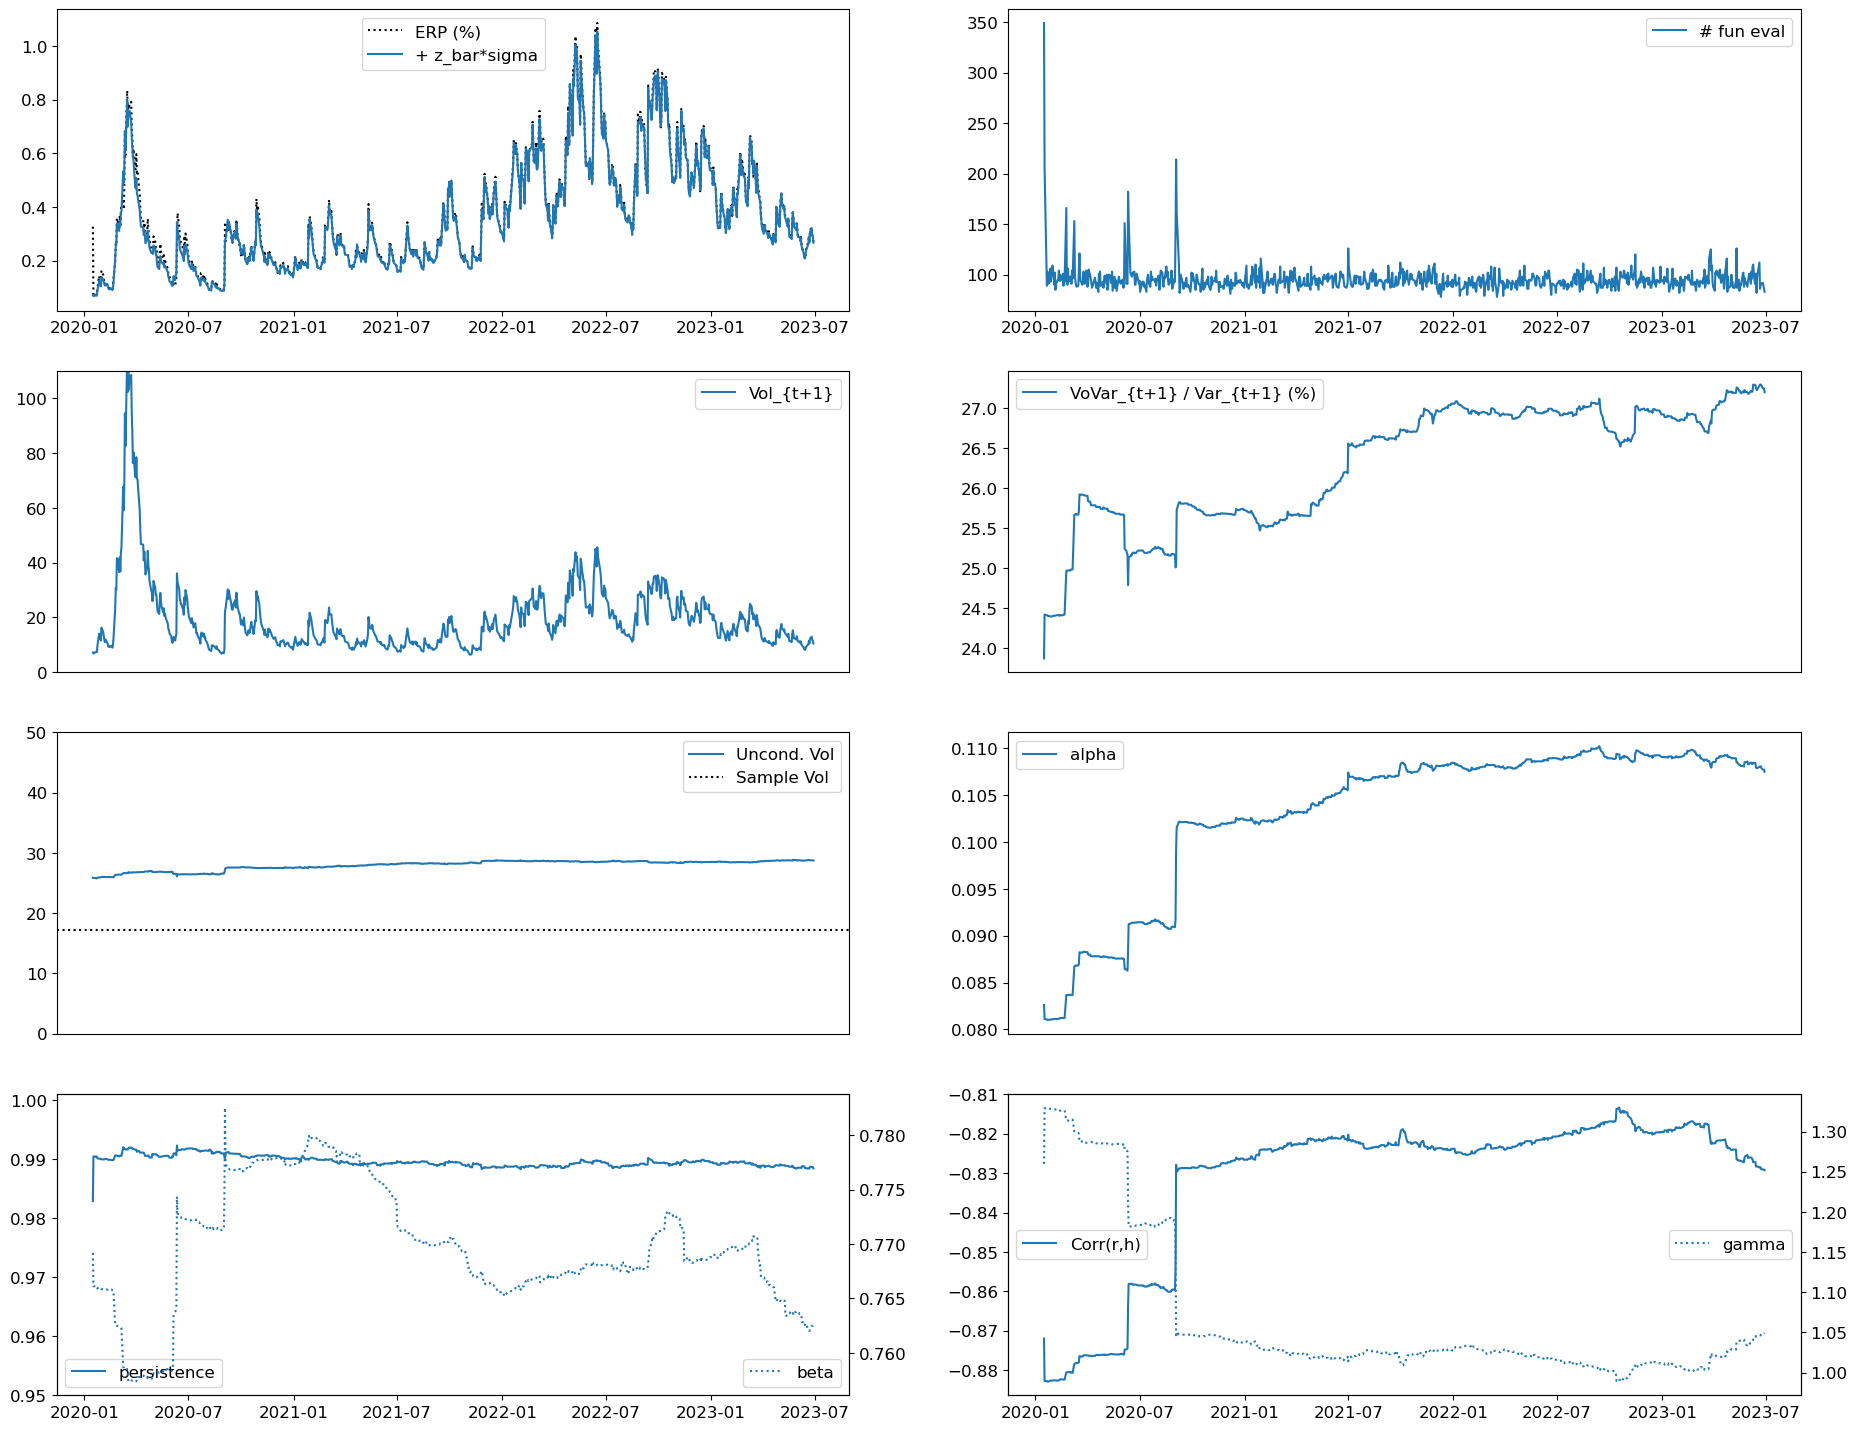

In [12]:
nm_fname = f'estimates_dv0_nm_sc.pkl'
nm_filename = os.path.join(".", nm_fname)
with open(nm_filename,'rb') as fh:
    estimates = pickle.load(fh)
plot_parameter_series(model, estimates);

In [13]:
# TODO:
# (1) Select the estimates from the first date in 2020
# (2) Use the estimates in 1) to simulate returns forward from that date, using the 
#     ngarch.simulateP function
# (3) With the simulated returns, get simulated S_0_T and use them to get the payoffs 
#     of the note below
# (4) Tabulate the first 4 moments of the note's returns (payoff / P_0 - 1) and plot the 
#     distribution against the distribution of the UA's return
# (5) Find the date at which the volatility peaks in the above graph. Use the (single) 
#     realized trajectory of the returns on the UA to get S_0_t and update the note's 
#     history
# (6) Load the estimates at this new date and repeat (2) to (4) above using these new 
#     estimates to simulate paths for the UA from t (as obtained in 5) to T (the maturity). 
#     In this case, the payoffs will be computed on S_t_T (conditioning on the history 
#     S_0_t provided to update_history). Make sure to organize between (2) to (4) into
#     functions whenever it can be reused for (6). Confirm that update_history did its job.
# (7) Compare the results in (4) and (6)

# NBC1155, Recovery Note Securities linked to the S&P/TSX 60 Index Series 4 
# https://nbcstructuredsolutions.ca/detailProduit.aspx?lequel=600
# Assume that the note is issued on the first business day in 2020 (cf. (1) above)


def simulate_model(estimates, date, model_vol, S_0, n_days, n_paths, rf):

    row_index = estimates.index.get_loc(date)
    estimate = estimates.iloc[row_index]

    model = model_vol()

    for param_name, param_value in estimate.items():
        if param_name in model.params:
            model.params[param_name].value = param_value

    h_tp1_value = estimate['h_tp1']

    ex_r, h, z = model.simulateP(S_t0=S_0, n_days=n_days, n_paths=n_paths, h_tp1=h_tp1_value, z=None, pv=None)

    print(model.get_pv())

    n_days, n_paths = ex_r.shape
    S_0_T = np.zeros((n_days + 1, n_paths))
    S_0_T[0, :] = S_0 

    for t in range(1, n_days + 1):
        S_0_T[t, :] = S_0_T[t - 1, :] * (np.exp(ex_r[t - 1, :] + rf))
    
    return S_0_T, ex_r, h, z

def calculate_stats(returns):
    mean_note_rt = np.mean(returns)
    variance_note_rt = np.var(returns)
    skewness_note_rt = stats.skew(returns)
    kurtosis_note_rt = stats.kurtosis(returns)

    return [mean_note_rt, variance_note_rt, skewness_note_rt, kurtosis_note_rt]


{'lmbda': 0.04545638151915643, 'omega': 2.231155640674082e-06, 'alpha': 0.08261109099490568, 'beta': 0.7691784918242821, 'gamma': 1.2596458116593787}
note returns     value
        Mean  0.577806
    Variance  0.129660
    Skewness -0.214056
    Kurtosis  0.498414


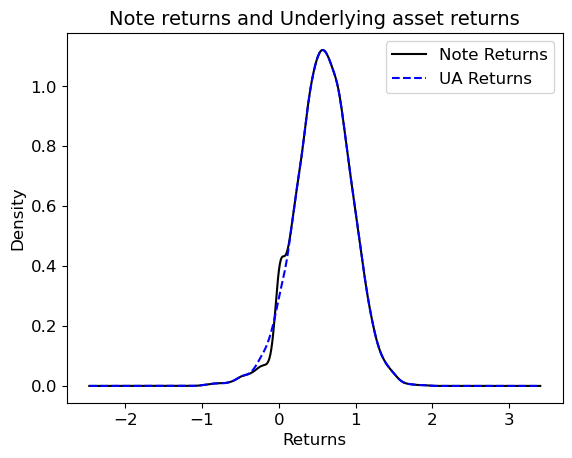

In [20]:
S_0 = 100
P_0 = S_0 # (P)rincipal: The note is issued at par with the UA
K = S_0
H = 0.65*S_0
T = 3

note = DownAndOutPut(S_0, K, H) + Spot(S_0)

# （1） read the parameters from the first date in 2020
issue_date = '2020-01-16'
risk_free_rt = (1+0.05)**(1/252) - 1
n_paths = 10000

S_0_T, ex_r, h, z = simulate_model(estimates, issue_date, ngarch, S_0, n_days=T*252, n_paths=n_paths, rf=risk_free_rt)

note_returns = (note._payoff(S_0_T) / S_0) - 1

stats_rt = calculate_stats(note_returns)

# (4) Tabulate the first 4 moments of the note's returns (payoff / P_0 - 1) 
table_note_rt = pd.DataFrame({
    'note returns': ['Mean', 'Variance', 'Skewness', 'Kurtosis'],
    'value': stats_rt
})

print(table_note_rt.to_string(index=False))

# (4) plot the note return distribution against the distribution of the UA's return
UA_returns = (Spot(S_0) ._payoff(S_0_T) / S_0) - 1

pd.Series(note_returns).plot(kind='kde', label='Note Returns', color='black', linestyle='-')
pd.Series(UA_returns).plot(kind='kde', label='UA Returns', color='blue', linestyle='--')
plt.xlabel('Returns')
plt.title('Note returns and Underlying asset returns')
plt.legend()
plt.show()

Date with volatility peak: 2020-03-16 00:00:00
{'lmbda': 0.007196582226689507, 'omega': 2.366777611707464e-06, 'alpha': 0.08681613432196555, 'beta': 0.7584960114389487, 'gamma': 1.2981741156917415}
note returns     value  value_max_vol
        Mean  0.577806       0.378358
    Variance  0.129660       0.496304
    Skewness -0.214056       0.244173
    Kurtosis  0.498414      -0.076259


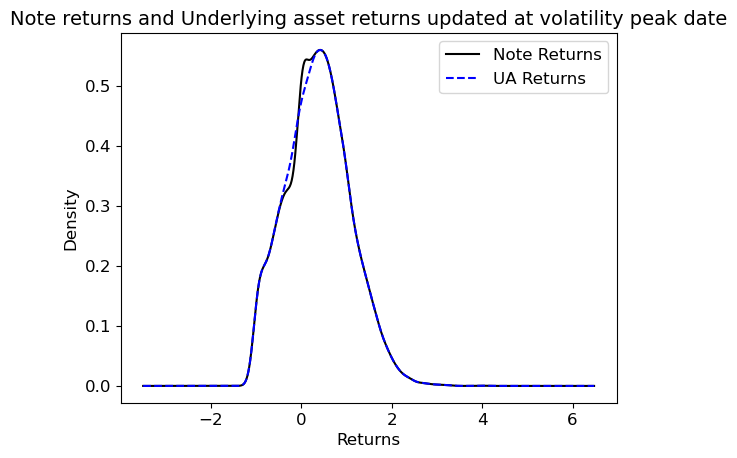

In [21]:
# (5) Find the date at which the volatility peaks in the above graph
vol = 100*np.sqrt(252*estimates.h_tp1)
max_vol_date = vol.idxmax()
print("Date with volatility peak:", max_vol_date)

# (5) Use the (single) realized trajectory of the returns on the UA to get S_0_t and update the note's history
dates = pd.date_range(start=issue_date, end=max_vol_date, freq='B')

calendar = USFederalHolidayCalendar()
holidays = calendar.holidays(start=dates.min(), end=dates.max())
dates = dates.drop(holidays)
num_trading_days = len(dates)

erp_max_vol = pd.concat([estimates.loc[issue_date:max_vol_date, 'erp']]*n_paths, axis=1)

S_0_T_single = np.zeros((num_trading_days + 1, n_paths))

S_0_T_single[0, :] = S_0 

for t in range(1, num_trading_days + 1):
    S_0_T_single[t, :] = S_0_T_single[t - 1, :] * (np.exp(erp_max_vol.iloc[t - 1, :] + risk_free_rt))

S_0_max_vol = S_0_T_single[-1]

# (6) Load the estimates at this new date and repeat (2) to (4) above

S_0_T_remaining, ex_r_max_vol, h_max_vol, z_max_vol = simulate_model(estimates, max_vol_date, ngarch, S_0=S_0_max_vol[0], n_days=T*252-num_trading_days, n_paths=n_paths, rf=risk_free_rt)

S_0_T_max_vol = np.vstack([S_0_T_single, S_0_T_remaining])

note_max_vol = DownAndOutPut(S_0, K, H) + Spot(S_0)

note_returns_max_vol = (note_max_vol._payoff(S_0_T_max_vol) / S_0) - 1

# (7) Compare the results in (4) and (6)
stats_rt_max_vol = calculate_stats(note_returns_max_vol)

# (4) Tabulate the first 4 moments of the note's returns (payoff / P_0 - 1) 
table_note_rt = pd.DataFrame({
    'note returns': ['Mean', 'Variance', 'Skewness', 'Kurtosis'],
    'value': stats_rt,
    'value_max_vol': stats_rt_max_vol
})

print(table_note_rt.to_string(index=False))

UA_returns_max_vol = (Spot(S_0) ._payoff(S_0_T_max_vol) / S_0) - 1

pd.Series(note_returns_max_vol).plot(kind='kde', label='Note Returns', color='black', linestyle='-')
pd.Series(UA_returns_max_vol).plot(kind='kde', label='UA Returns', color='blue', linestyle='--')
plt.xlabel('Returns')
plt.title('Note returns and Underlying asset returns updated at volatility peak date')
plt.legend()
plt.show()